# Training PPO on LunarLander, step by step

This notebook opens up what `rlgames-sb train --config configs/lunarlander_ppo.yaml`
does:

1. **The environment**: the state vector, the actions and the reward
2. **One training example**: a single transition `(s, a, r, s', done)`
3. **A random baseline**: the score to beat
4. **The agent**: PPO's actor-critic network
5. **One PPO update, by hand**: rollout → advantages → clipped loss → gradient step
6. **The full training loop**: `model.learn()`
7. **Evaluation**: trained agent vs random
8. **Saving**, so the CLI can continue training

Where the Breakout notebook (`breakout_dqn.ipynb`) learns from pixels with an
off-policy, value-based method (DQN), this one learns from a small state
vector with an on-policy, policy-gradient method (PPO).

In [1]:
import os
import time
from pathlib import Path

# Run from the repo root so saves land in ./saves, like the CLI.
if Path.cwd().name == "notebooks":
    os.chdir("..")

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3.common.evaluation import evaluate_policy

from rl_games_sb import config, envs, registry

cfg = config.load("configs/lunarlander_ppo.yaml")
ENV_ID = cfg.env
print(f"env: {cfg.env}, algo: {cfg.algo}")
print(f"hyperparams: {cfg.hyperparams}")

env: LunarLander-v3, algo: ppo
hyperparams: {'n_steps': 1024, 'batch_size': 64, 'n_epochs': 4, 'gamma': 0.999, 'gae_lambda': 0.98, 'ent_coef': 0.01, 'device': 'cpu'}


## 1. The environment

The lander starts near the top with a random push. The goal is to land
between the two flags, gently and upright.

Unlike Atari, the observation is not an image but **8 numbers** describing the
lander, so the agent uses a small MLP instead of a CNN.

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space     : Discrete(4)


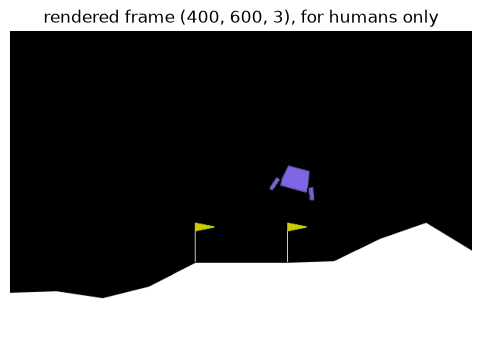

In [2]:
env = envs.make(ENV_ID)

print("Observation space:", env.observation_space)
print("Action space     :", env.action_space)

raw_env = gym.make(ENV_ID, render_mode="rgb_array")
raw_env.reset(seed=0)
for _ in range(40):
    raw_env.step(0)
frame = raw_env.render()
raw_env.close()

plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.title(f"rendered frame {frame.shape}, for humans only")
plt.axis("off")
plt.show()

| index | observation | | action | meaning |
|---|---|---|---|---|
| 0, 1 | x, y position (landing pad at 0, 0) | | 0 | do nothing |
| 2, 3 | x, y velocity | | 1 | fire left engine (pushes right) |
| 4 | angle | | 2 | fire main engine (pushes up) |
| 5 | angular velocity | | 3 | fire right engine (pushes left) |
| 6, 7 | left / right leg touching ground (0 or 1) | | | |

**Reward** is shaped to guide learning: moving closer to the pad and slowing
down earn reward, moving away and tilting cost it. Each leg contact is +10,
firing the main engine costs 0.3 per frame (side engines 0.03), and the
episode ends with **+100 for landing** or **−100 for crashing**. An episode
scoring **200+** counts as solved.

## 2. One training example

Each step produces one **transition** `(s, a, r, s', done)`. DQN stores these
in a replay buffer and reuses them many times. PPO is **on-policy**: it
collects a fresh batch of transitions with the current policy (a *rollout*),
learns from it for a few epochs, then throws it away.

In [3]:
OBS_NAMES = ["x", "y", "vx", "vy", "angle", "ang_vel", "left_leg", "right_leg"]

s, _ = env.reset(seed=0)
a = 2  # main engine
s_next, r, terminated, truncated, info = env.step(a)

print(f"{'':>10} {'s':>9} {'s_next':>9}")
for name, v0, v1 in zip(OBS_NAMES, s, s_next):
    print(f"{name:>10} {v0:>+9.4f} {v1:>+9.4f}")
print(f"\na: {a} (main engine)   r: {r:+.4f}   done: {terminated}   truncated: {truncated}")

                   s    s_next
         x   +0.0057   +0.0114
         y   +1.3990   +1.3880
        vx   +0.5780   +0.5793
        vy   -0.5283   -0.4904
     angle   -0.0066   -0.0130
   ang_vel   -0.1309   -0.1279
  left_leg   +0.0000   +0.0000
 right_leg   +0.0000   +0.0000

a: 2 (main engine)   r: +2.5672   done: False   truncated: False


## 3. Random baseline

Firing engines at random crashes the lander almost every time:

In [4]:
def play_random(n_episodes: int) -> list[float]:
    rewards = []
    for ep in range(n_episodes):
        env.reset(seed=ep)
        done, total = False, 0.0
        while not done:
            _, r, terminated, truncated, _ = env.step(env.action_space.sample())
            total += r
            done = terminated or truncated
        rewards.append(total)
    return rewards

random_rewards = play_random(20)
print(f"Random policy: {np.mean(random_rewards):.1f} +/- {np.std(random_rewards):.1f}")

Random policy: -193.9 +/- 116.5


## 4. The agent: PPO

PPO is an **actor-critic** method. One network has two heads:

- the **actor** (policy) `π(a | s)`: a probability for each action. The agent
  *samples* from it while training, which is how it explores (no ε-greedy).
- the **critic** (value) `V(s)`: the expected future reward from state `s`.
  It is only used during training, to judge whether an action turned out
  better or worse than expected.

The hyperparameters come from `configs/lunarlander_ppo.yaml`, as with
`rlgames-sb train --config`.

In [5]:
model = registry.create(cfg.algo, ENV_ID, **cfg.hyperparams)
model.verbose = 0  # the notebook prints its own summaries

print(model.policy)
print(f"\nParameters: {sum(p.numel() for p in model.policy.parameters()):,}")
print(f"Device    : {model.device}")

Using cpu device
Wrapping the env in a DummyVecEnv.


ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=4, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)

Parameters: 9,797
Device    : cpu


SB3's default MLP gives the actor and the critic separate hidden layers
(`policy_net` and `value_net`, two layers of 64 each). `action_net` turns the
actor's features into 4 action logits and `value_net` turns the critic's into
one number.

Before training, the policy is close to uniform and the value is noise:

In [6]:
ACTIONS = ["noop", "left", "main", "right"]

def inspect_state(model, obs):
    obs_t, _ = model.policy.obs_to_tensor(obs)
    with torch.no_grad():
        probs = model.policy.get_distribution(obs_t).distribution.probs[0].cpu().numpy()
        value = model.policy.predict_values(obs_t)[0, 0].item()
    return probs, value

probs, value = inspect_state(model, s)
for name, p in zip(ACTIONS, probs):
    print(f"  π({name:<5} | s) = {p:.3f}")
print(f"  V(s)           = {value:+.3f}")

  π(noop  | s) = 0.250
  π(left  | s) = 0.249
  π(main  | s) = 0.250
  π(right | s) = 0.251
  V(s)           = +0.061


## 5. One PPO update, by hand

### Collect a rollout and compute advantages

PPO runs the current policy for `n_steps` steps (1024 here), recording for
each step the state, action, reward, the action's log-probability and the
critic's value.

Then it computes each action's **advantage** `A`: how much better it turned
out than the critic expected. PPO uses GAE (Generalized Advantage Estimation),
which blends one-step and multi-step estimates:

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t), \qquad
A_t = \delta_t + \gamma\lambda\, A_{t+1}
$$

The critic's training target, the **return**, is `A_t + V(s_t)`.

`model.learn()` for exactly one rollout leaves it in `model.rollout_buffer`:

In [7]:
model.learn(total_timesteps=model.n_steps)
buf = model.rollout_buffer

print(f"Rollout: {buf.buffer_size} steps")
print("\n  t | action | reward  |  V(s)   | advantage | return")
for t in range(8):
    print(
        f"{t:>3} | {ACTIONS[int(buf.actions[t, 0])]:<6} | {buf.rewards[t, 0]:>+7.3f} "
        f"| {buf.values[t, 0]:>+7.3f} | {buf.advantages[t, 0]:>+9.3f} | {buf.returns[t, 0]:>+7.3f}"
    )

Rollout: 1024 steps

  t | action | reward  |  V(s)   | advantage | return
  0 | left   |  +1.866 |  -0.007 |   -23.542 | -23.549
  1 | noop   |  +1.045 |  -0.020 |   -25.940 | -25.960
  2 | right  |  -0.286 |  -0.021 |   -27.561 | -27.583
  3 | noop   |  +0.540 |  -0.012 |   -27.869 | -27.881
  4 | right  |  -0.522 |  -0.014 |   -29.016 | -29.030
  5 | main   |  -1.646 |  -0.007 |   -29.111 | -29.118
  6 | noop   |  +0.080 |  -0.007 |   -28.054 | -28.061
  7 | noop   |  -0.097 |  -0.009 |   -28.735 | -28.744


### The clipped PPO loss

For a minibatch of the rollout, PPO compares the probability the **current**
policy gives each action with the probability the **old** policy (the one
that collected the rollout) gave it:

$$
\rho = \frac{\pi_\theta(a \mid s)}{\pi_{\text{old}}(a \mid s)}
$$

and maximizes $\min(\rho A,\ \text{clip}(\rho, 1-\epsilon, 1+\epsilon)\, A)$.
Actions with positive advantage become more likely and negative ones less
likely. The clip (ε = 0.2) stops the new policy from moving too far from the
one that collected the data, which keeps the update stable. This is the
"proximal" in PPO.

The total loss adds the critic's error and an entropy bonus that keeps the
policy from becoming deterministic too early:

$$
L = L_{\text{policy}} + c_v\, (V(s) - \text{return})^2 - c_e\, \text{entropy}
$$

In [8]:
clip = model.clip_range(1.0)
batch = next(buf.get(model.batch_size))

def ppo_loss(model, batch):
    values, log_prob, entropy = model.policy.evaluate_actions(
        batch.observations, batch.actions.long().flatten()
    )
    adv = batch.advantages
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)  # normalized per minibatch, as in SB3

    ratio = torch.exp(log_prob - batch.old_log_prob)
    policy_loss = -torch.min(ratio * adv, torch.clamp(ratio, 1 - clip, 1 + clip) * adv).mean()
    value_loss = torch.nn.functional.mse_loss(batch.returns, values.flatten())
    entropy_loss = -entropy.mean()
    loss = policy_loss + model.vf_coef * value_loss + model.ent_coef * entropy_loss
    return loss, policy_loss, value_loss, entropy_loss, ratio

loss, policy_loss, value_loss, entropy_loss, ratio = ppo_loss(model, batch)
print(f"minibatch of {len(batch.actions)} transitions")
print(f"  policy loss  : {policy_loss.item():+.4f}")
print(f"  value loss   : {value_loss.item():+.4f}")
print(f"  entropy loss : {entropy_loss.item():+.4f}")
print(f"  total loss   : {loss.item():+.4f}")
print(f"  ratio range  : {ratio.min().item():.4f} .. {ratio.max().item():.4f}")

minibatch of 64 transitions
  policy loss  : -0.0082
  value loss   : +7441.4189
  entropy loss : -1.3837
  total loss   : +3720.6875
  ratio range  : 0.8745 .. 1.1173


SB3 already ran its update on this rollout, so the policy has moved since it
collected these transitions and the ratios are no longer exactly 1. The value
loss dominates for now: the untrained critic predicts about 0 while the
returns are around −100, so early updates mostly teach the critic. Take one
more gradient step, as `PPO.train()` does for every minibatch: backprop,
clip gradients, optimizer step.

In [9]:
optimizer = model.policy.optimizer
optimizer.zero_grad()
loss.backward()
torch.nn.utils.clip_grad_norm_(model.policy.parameters(), model.max_grad_norm)
optimizer.step()

loss_after, *_ = ppo_loss(model, batch)
print(f"Loss before: {loss.item():+.4f}")
print(f"Loss after : {loss_after.item():+.4f}")

Loss before: +3720.6875
Loss after : +3718.2344


That is all of PPO's learning.

## 6. The full training loop

`model.learn()` repeats:

1. **Collect** a rollout of `n_steps` (1024) with the current policy, sampling actions
2. **Compute** advantages and returns with GAE (γ = 0.999, λ = 0.98)
3. **Update** for `n_epochs` (4) passes over the rollout, in shuffled minibatches
   of `batch_size` (64): the loss above, one gradient step per minibatch
4. **Discard** the rollout and start again with the improved policy

The config trains for 1M timesteps. `TIMESTEPS` here is smaller so the cell
runs in a few minutes on a CPU, but it is enough to see the lander learn.

In [10]:
TIMESTEPS = 500_000

start = time.time()
model.learn(total_timesteps=TIMESTEPS, reset_num_timesteps=False)
elapsed = time.time() - start
print(f"Trained {TIMESTEPS:,} steps in {elapsed:.0f}s ({TIMESTEPS / elapsed:.0f} steps/s)")
print(f"Total timesteps so far: {model.num_timesteps:,}")

Trained 500,000 steps in 178s (2803 steps/s)
Total timesteps so far: 501,760


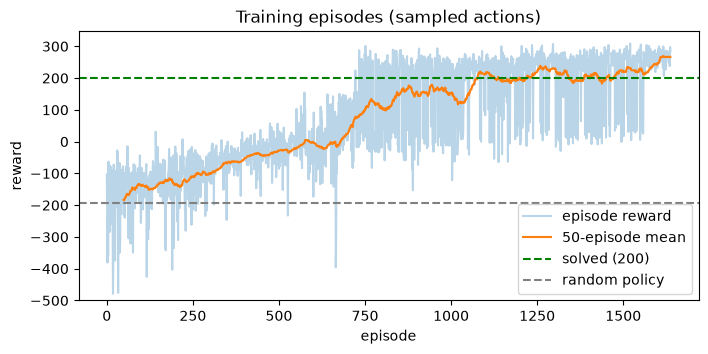

In [11]:
# The Monitor wrapper recorded every training episode's reward
episode_rewards = model.get_env().envs[0].get_episode_rewards()

window = 50
plt.figure(figsize=(8, 3.5))
plt.plot(episode_rewards, alpha=0.3, label="episode reward")
rolling = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
plt.plot(range(window - 1, len(episode_rewards)), rolling, label=f"{window}-episode mean")
plt.axhline(200, color="green", linestyle="--", label="solved (200)")
plt.axhline(np.mean(random_rewards), color="gray", linestyle="--", label="random policy")
plt.ylim(bottom=-500)
plt.xlabel("episode")
plt.ylabel("reward")
plt.title("Training episodes (sampled actions)")
plt.legend()
plt.show()

## 7. Evaluation

The agent now plays greedily: the most likely action instead of a sampled
one. This is what `rlgames-sb load ppo --env LunarLander-v3 --eval` reports.

In [12]:
mean, std = evaluate_policy(model, envs.make(ENV_ID), n_eval_episodes=20)
print(f"Random policy : {np.mean(random_rewards):.1f} +/- {np.std(random_rewards):.1f}")
print(f"Trained agent : {mean:.1f} +/- {std:.1f}")
print("Solved!" if mean >= 200 else "Not solved yet (200+). Train longer: see section 8.")

Random policy : -193.9 +/- 116.5
Trained agent : 258.7 +/- 19.2
Solved!


### One landing, step by step

The trajectory of one greedy episode, colored by the action taken, plus what
the trained policy and critic think at the start:

Trained policy at the initial state from section 2:
  π(noop  | s) = 0.002
  π(left  | s) = 0.472
  π(main  | s) = 0.526
  π(right | s) = 0.000
  V(s)           = +216.4   (expected return from here)


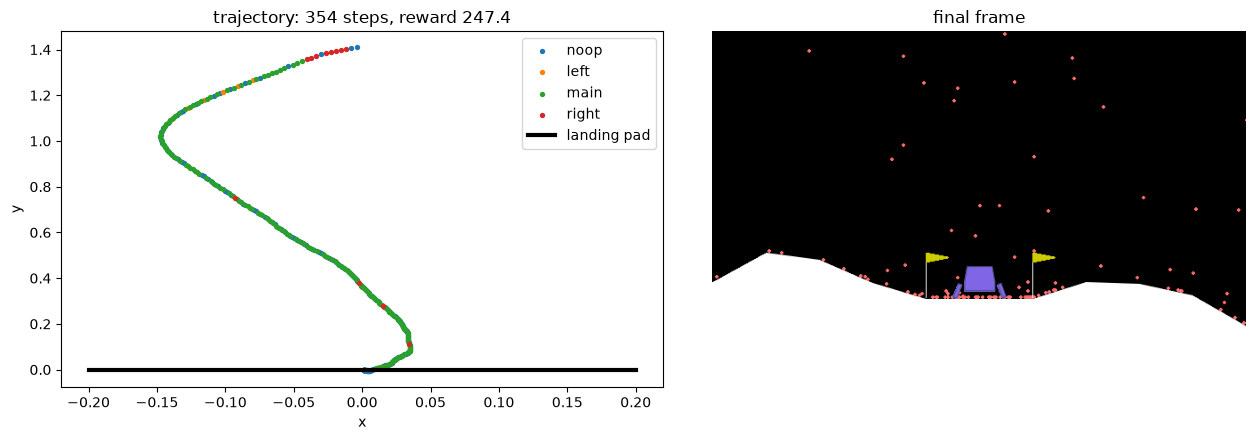

In [13]:
probs, value = inspect_state(model, s)
print("Trained policy at the initial state from section 2:")
for name, p in zip(ACTIONS, probs):
    print(f"  π({name:<5} | s) = {p:.3f}")
print(f"  V(s)           = {value:+.1f}   (expected return from here)")

render_env = envs.make(ENV_ID, render_mode="rgb_array")
obs, _ = render_env.reset(seed=7)
states, actions, total = [obs], [], 0.0
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, r, terminated, truncated, _ = render_env.step(action)
    states.append(obs)
    actions.append(int(action))
    total += r
    done = terminated or truncated
final_frame = render_env.render()
render_env.close()

states = np.array(states)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, name in enumerate(ACTIONS):
    idx = [t for t, act in enumerate(actions) if act == i]
    axes[0].scatter(states[idx, 0], states[idx, 1], s=8, label=name)
axes[0].plot([-0.2, 0.2], [0, 0], "k-", linewidth=3, label="landing pad")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title(f"trajectory: {len(actions)} steps, reward {total:.1f}")
axes[0].legend()
axes[1].imshow(final_frame)
axes[1].set_title("final frame")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Save, and continue from the CLI

The model is saved where the CLI looks for it, so training can continue from
the terminal (`registry.load_or_create` resumes from the save):

```bash
rlgames-sb train  ppo --env LunarLander-v3 --timesteps 500000
rlgames-sb load   ppo --env LunarLander-v3 --eval
rlgames-sb render ppo --env LunarLander-v3
```

In [14]:
path = registry.save_path(cfg.algo, ENV_ID)
model.save(path)
env.close()
print(f"Saved to {path}")

Saved to saves\ppo_LunarLander-v3.zip
